# Insurance Risk Analytics — Exploratory Data Analysis (EDA)

## Objective

This notebook performs Exploratory Data Analysis (EDA) on the insurance dataset to understand risk patterns, data quality, and key drivers of insurance claims and premiums.

The analysis focuses on:
- Data structure and quality
- Univariate and multivariate analysis
- Geographic risk trends
- Outlier detection
- Financial risk relationships

## Load Dataset

We load the dataset using a reusable function from `src`.

In [11]:
df = pd.read_csv(
    "../data/MachineLearningRating_v3.txt",
    sep="|"
)

df.head()

C:\Users\redea\AppData\Local\Temp\ipykernel_19212\1080917320.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


## 1. Data Summarization

We inspect dataset structure, data types, and summary statistics for key variables such as TotalPremium and TotalClaims.

In [12]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    990562 non-null   str    
 12  Country                   1000098 non-null  str    
 13  Province                  1000098 non-

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05


## 2. Data Quality Assessment

We check missing values, duplicates, and inconsistent data types.

In [13]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

### Missing Value Strategy
- Numerical: median imputation (if needed)
- Categorical: mode imputation or 'Unknown'
- Rows with critical missing values may be dropped

In [14]:
df.dtypes
df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"])

## 3. Univariate Analysis

We analyze distributions of key numerical and categorical variables.

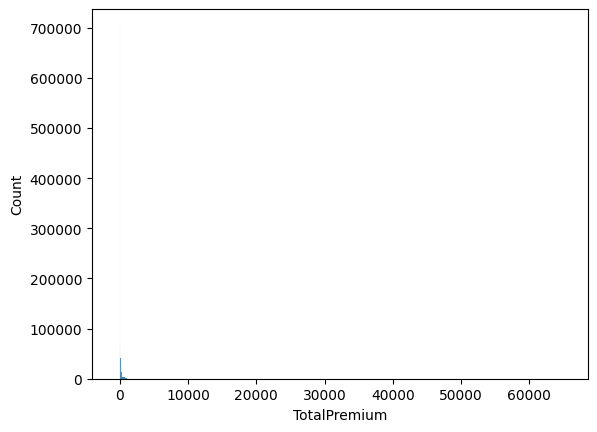

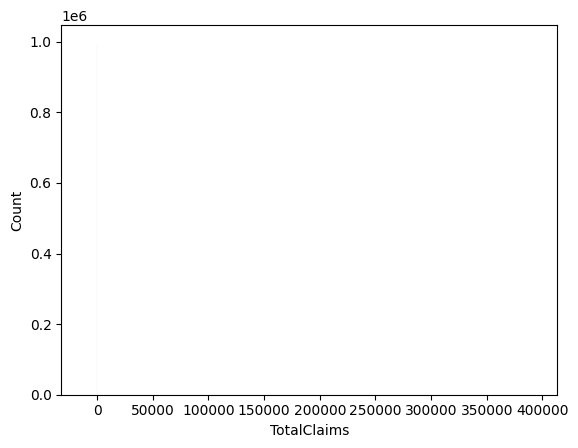

In [16]:
import matplotlib.pyplot as plt

sns.histplot(df["TotalPremium"])
plt.show()

sns.histplot(df["TotalClaims"])
plt.show()

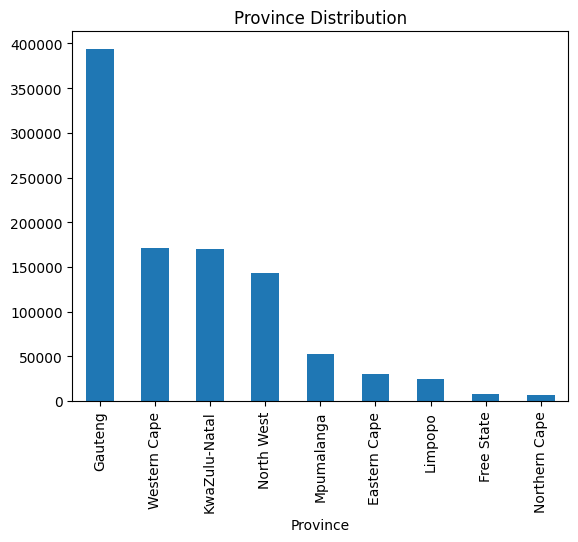

In [17]:
df["Province"].value_counts().plot(kind="bar")
plt.title("Province Distribution")
plt.show()

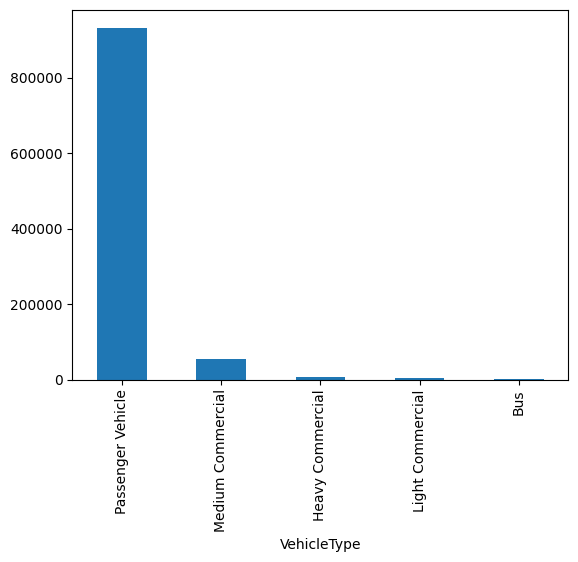

In [18]:
df["VehicleType"].value_counts().head(10).plot(kind="bar")
plt.show()

## 4. Bivariate & Multivariate Analysis

We analyze relationships between TotalPremium and TotalClaims across ZipCode and other variables.

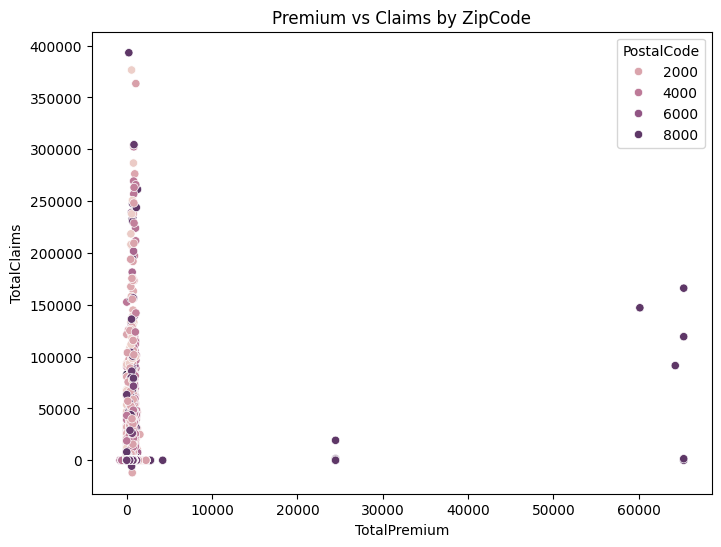

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims",
    hue="PostalCode"
)

plt.title("Premium vs Claims by ZipCode")
plt.show()

In [20]:
df.corr(numeric_only=True)

,UnderwrittenCoverID,PolicyID,IsVATRegistered,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
UnderwrittenCoverID,1.000000,0.916324,0.020838,-0.018206,0.083310,0.065886,-0.026910,0.084892,-0.038613,-0.023781,0.006728,NaN,0.003022,0.028029,0.065413,0.003011
PolicyID,0.916324,1.000000,0.033661,-0.034186,0.074428,0.067192,-0.028551,0.088083,-0.032198,-0.031438,0.005268,NaN,0.002141,0.025191,0.059572,0.002941
IsVATRegistered,0.020838,0.033661,1.000000,-0.037956,-0.205454,-0.010396,0.033334,-0.047206,-0.044592,0.013665,-0.005452,NaN,0.001628,-0.004599,-0.003797,-0.000479
PostalCode,-0.018206,-0.034186,-0.037956,1.000000,0.100995,0.009472,-0.042656,-0.139570,-0.195637,0.083857,-0.014861,NaN,0.001549,0.016138,0.007394,0.000412
mmcode,0.083310,0.074428,-0.205454,0.100995,1.000000,-0.088748,-0.100871,0.196766,0.033500,0.021488,-0.003286,NaN,-0.010734,-0.003154,0.012419,-0.000615
RegistrationYear,0.065886,0.067192,-0.010396,0.009472,-0.088748,1.000000,-0.034001,0.096951,0.176013,0.068109,0.148682,NaN,0.003872,0.065814,0.058666,0.005197
Cylinders,-0.026910,-0.028551,0.033334,-0.042656,-0.100871,-0.034001,1.000000,0.301620,0.325936,-0.259174,0.018561,NaN,0.001635,0.017942,0.006826,0.000043
cubiccapacity,0.084892,0.088083,-0.047206,-0.139570,0.196766,0.096951,0.301620,1.000000,0.566559,-0.298624,0.046180,NaN,-0.002233,0.038396,0.042554,0.001228
kilowatts,-0.038613,-0.032198,-0.044592,-0.195637,0.033500,0.176013,0.325936,0.566559,1.000000,-0.115124,0.035497,NaN,-0.002167,0.039054,0.035024,0.003099
NumberOfDoors,-0.023781,-0.031438,0.013665,0.083857,0.021488,0.068109,-0.259174,-0.298624,-0.115124,1.000000,-0.054761,NaN,-0.000277,-0.006545,-0.008002,0.001700


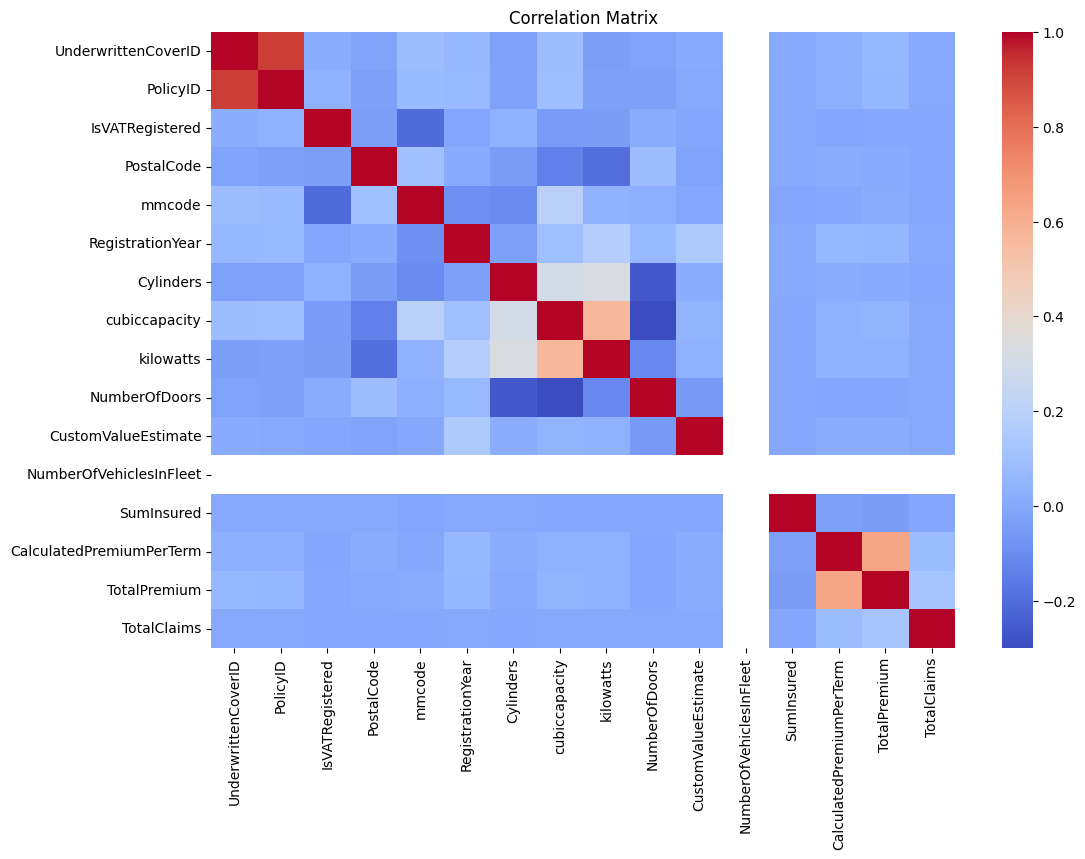

In [22]:
import seaborn as sns

def plot_correlation_matrix(df):
    plt.figure(figsize=(12, 8))
    sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.show()

plot_correlation_matrix(df)

## 5. Geographic Trends

We analyze how insurance risk varies across provinces.

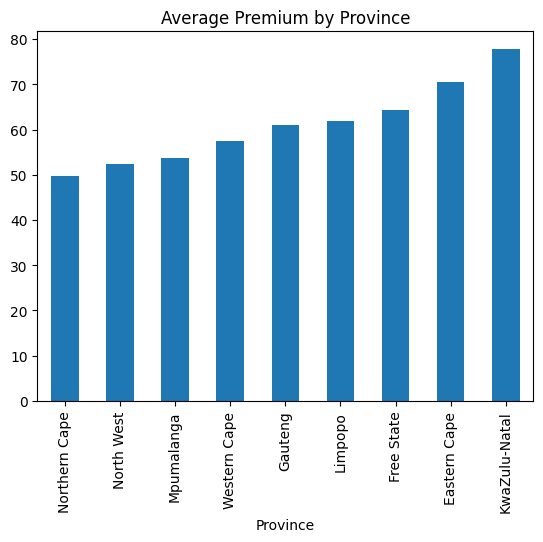

In [23]:
df.groupby("Province")["TotalPremium"].mean().sort_values().plot(kind="bar")
plt.title("Average Premium by Province")
plt.show()

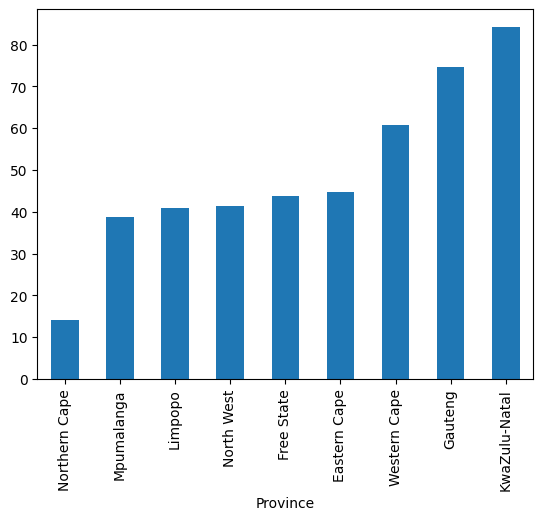

In [24]:
df.groupby("Province")["TotalClaims"].mean().sort_values().plot(kind="bar")
plt.show()

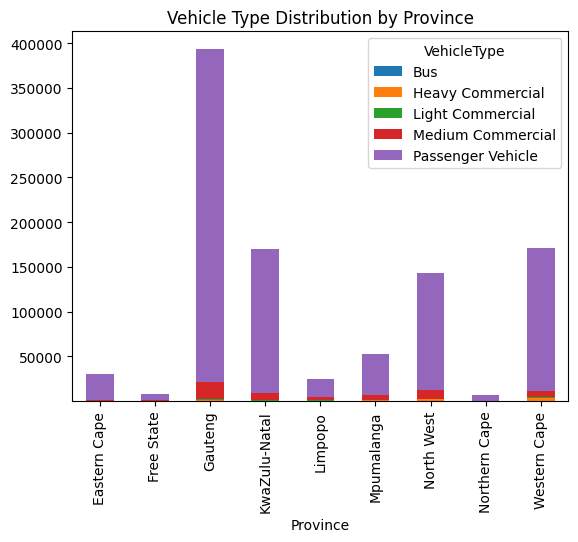

In [25]:
pd.crosstab(df["Province"], df["VehicleType"]).plot(kind="bar", stacked=True)
plt.title("Vehicle Type Distribution by Province")
plt.show()

## 6. Outlier Detection

We detect extreme values using boxplots.

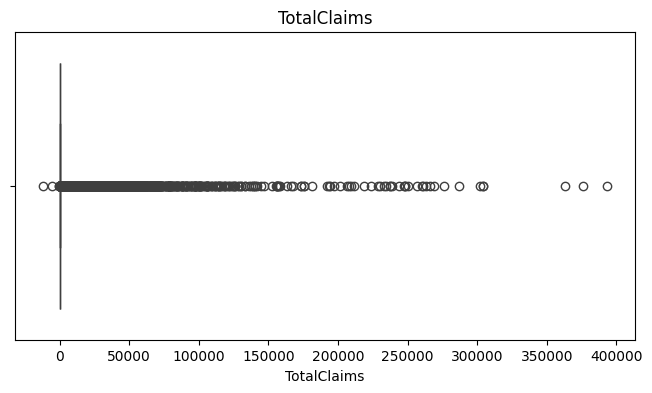

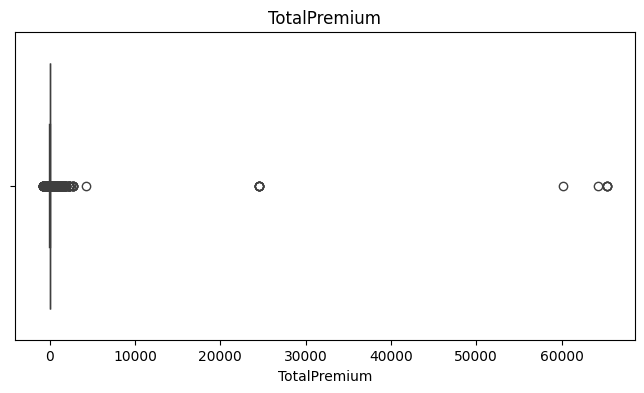

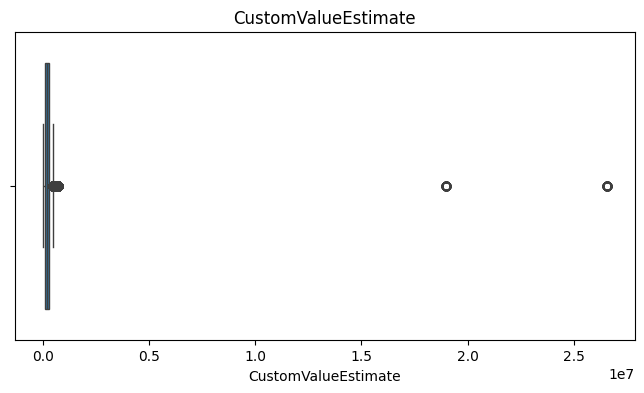

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_boxplot(df, col):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

plot_boxplot(df, "TotalClaims")
plot_boxplot(df, "TotalPremium")
plot_boxplot(df, "CustomValueEstimate")

## 7. Loss Ratio Analysis

Loss Ratio measures portfolio profitability.

It is defined as:

Loss Ratio = Total Claims / Total Premiums

In [28]:
loss_ratio = df["TotalClaims"].sum() / df["TotalPremium"].sum()
loss_ratio

np.float64(1.0477452570332206)

## segment analysis

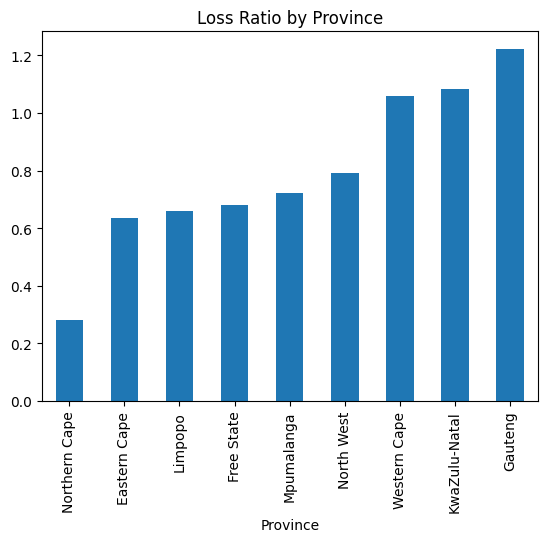

In [29]:
df.groupby("Province").apply(
    lambda x: x["TotalClaims"].sum() / x["TotalPremium"].sum()
).sort_values().plot(kind="bar")
plt.title("Loss Ratio by Province")
plt.show()

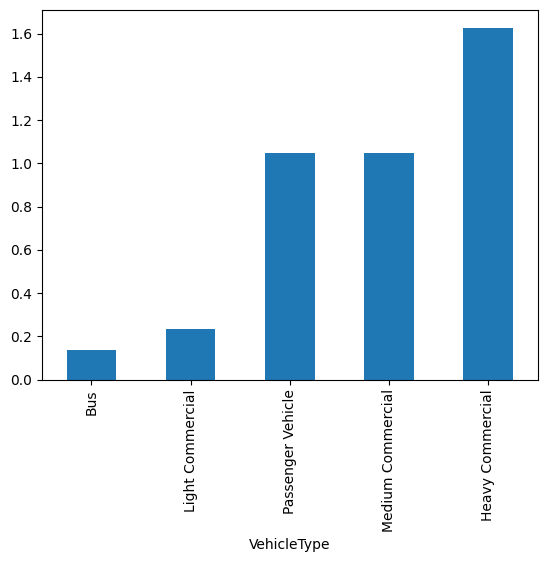

In [30]:
df.groupby("VehicleType").apply(
    lambda x: x["TotalClaims"].sum() / x["TotalPremium"].sum()
).sort_values().plot(kind="bar")
plt.show()

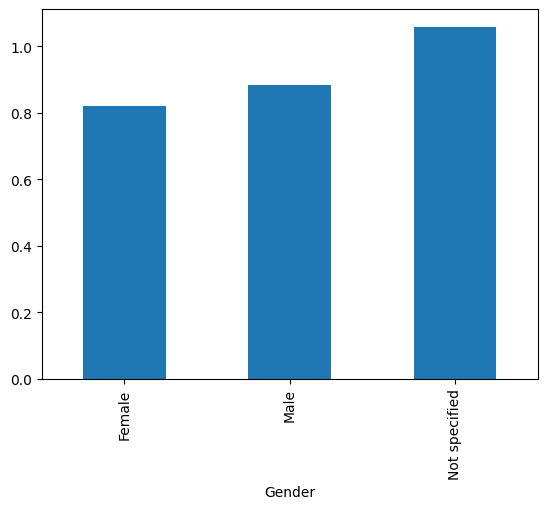

In [31]:
df.groupby("Gender").apply(
    lambda x: x["TotalClaims"].sum() / x["TotalPremium"].sum()
).plot(kind="bar")
plt.show()

## 8. Temporal Trends

We analyze how claims evolve over time (18-month period).

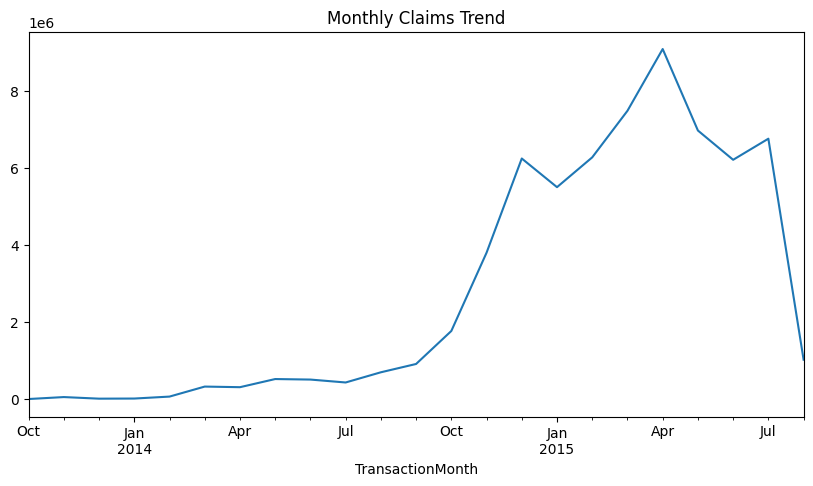

In [32]:
df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"])

monthly_claims = df.groupby(
    df["TransactionMonth"].dt.to_period("M")
)["TotalClaims"].sum()

monthly_claims.plot(figsize=(10,5))
plt.title("Monthly Claims Trend")
plt.show()

## 9. Vehicle Risk Analysis

We identify vehicle makes and models associated with highest and lowest claims.

In [33]:
df.groupby("make")["TotalClaims"].mean().sort_values(ascending=False).head(10)
df.groupby("make")["TotalClaims"].mean().sort_values().head(10)

make
CITROEN                                0.0
CHERY                                  0.0
FORD                                   0.0
DAIHATSU                               0.0
GEELY                                  0.0
HINO                                   0.0
HUMMER                                 0.0
HONDA                                  0.0
JINBEI                                 0.0
KIA                                    0.0
Name: TotalClaims, dtype: float64

## Plot 1 — Risk by Province

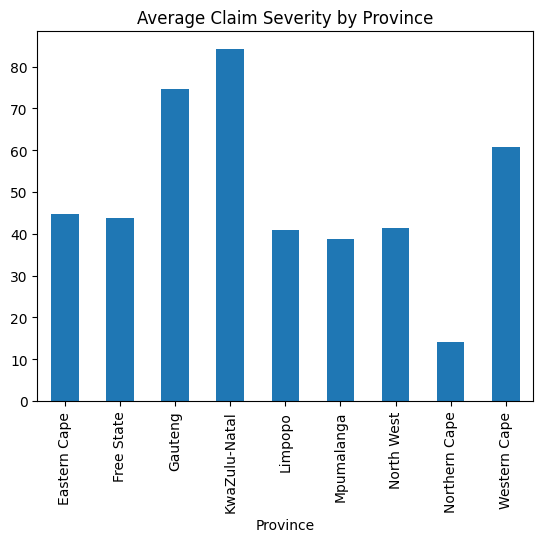

In [34]:
df.groupby("Province")["TotalClaims"].mean().plot(kind="bar")
plt.title("Average Claim Severity by Province")
plt.show()

## Plot 2 — Premium vs Claims (Risk scatter)

d:\Repos\insurance-risk-analytics\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


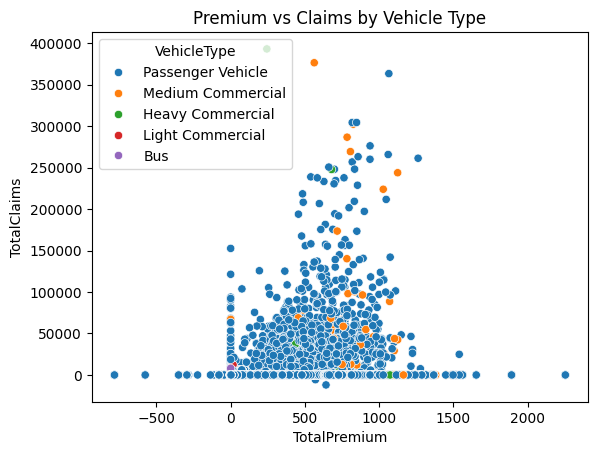

In [35]:
sns.scatterplot(data=df, x="TotalPremium", y="TotalClaims", hue="VehicleType")
plt.title("Premium vs Claims by Vehicle Type")
plt.show()

## Plot 3 — Temporal trend

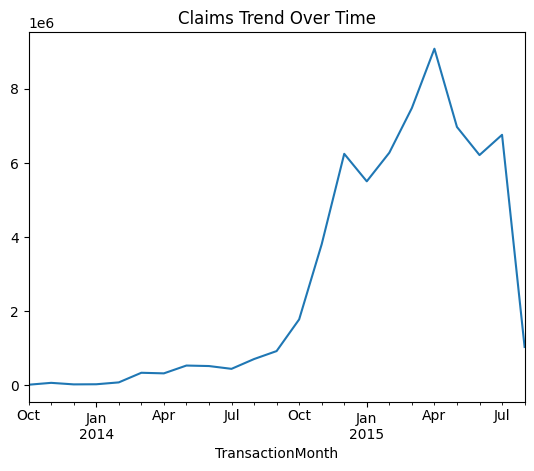

In [36]:
monthly_claims.plot()
plt.title("Claims Trend Over Time")
plt.show()

============================================================
EDA SUMMARY — KEY FINDINGS
============================================================

Dataset: 1,000,098 policies, 55 features
Period: 2013-10-01 00:00:00 to 2015-08-01 00:00:00

Portfolio Metrics:
  Overall Loss Ratio: 0.2164
  Total Premium: R61,911,562.70
  Total Claims: R64,867,546.17
  Total Margin: R-2,955,983.47

Risk Metrics:
  Claim Frequency: 0.28%
  Avg Claim (when claimed): R23,273.39

Geographic Risk:
  Highest risk province: Gauteng
  Lowest risk province: Free State